# Preprocessing Data Spasial - Lampung
**Kelompok 02 & 06 | Mahadata / Big Data IF25-40402**

Notebook ini memproses file `spasial_lampung_sampled.xlsx` hasil export Google Earth Engine:
1. **Langkah 1** — Parse koordinat dari kolom `.geo`
2. **Langkah 2** — Assign tiap titik ke kabupaten (nearest centroid)
3. **Langkah 3** — Agregasi elevasi & tutupan lahan per kabupaten

## Install & Import

In [ ]:
!pip install scipy openpyxl -q

import pandas as pd
import numpy as np
import json
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

print('Import selesai ✅')

Import selesai ✅


## Upload File
Upload file `spasial_lampung_sampled.xlsx` ke Colab terlebih dahulu.

In [ ]:
from google.colab import files
uploaded = files.upload()  # upload spasial_lampung_sampled.xlsx

Saving spasial_lampung_sampled.xlsx to spasial_lampung_sampled (1).xlsx


## Load & Eksplorasi Awal

In [ ]:
df = pd.read_excel('spasial_lampung_sampled.xlsx')

print('Shape:', df.shape)
print('Kolom:', df.columns.tolist())
print()
df.head()

Shape: (4905, 4)
Kolom: ['system:index', 'elevasi', 'tutupan_lahan', '.geo']



,system:index,elevasi,tutupan_lahan,.geo
0,0,7,8,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,1,8,2,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,2,8,2,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,3,8,2,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,4,7,8,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


In [ ]:
# Cek tipe data
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())

system:index      int64
elevasi           int64
tutupan_lahan     int64
.geo             object
dtype: object

Missing values:
system:index     0
elevasi          0
tutupan_lahan    0
.geo             0
dtype: int64


In [ ]:
# Statistik elevasi
print('=== Statistik Elevasi ===')
print(df['elevasi'].describe())
print()

# Distribusi tutupan lahan
print('=== Distribusi Kode Tutupan Lahan (MODIS) ===')
print(df['tutupan_lahan'].value_counts())

=== Statistik Elevasi ===
count    4905.000000
mean      185.771865
std       292.655997
min         0.000000
25%        24.000000
50%        49.000000
75%       180.000000
max      1765.000000
Name: elevasi, dtype: float64

=== Distribusi Kode Tutupan Lahan (MODIS) ===
tutupan_lahan
14    1949
8     1166
2      836
12     407
9      380
11      59
17      45
10      39
13      24
Name: count, dtype: int64


## Langkah 1 — Parse Koordinat dari Kolom `.geo`

Kolom `.geo` berisi JSON string seperti:
```json
{"geodesic":false,"type":"Point","coordinates":[105.336, -3.730]}
```
Kita ekstrak jadi kolom `lon` dan `lat`.

In [ ]:
def parse_geo(geo_str):
    geo = json.loads(geo_str)
    lon = geo['coordinates'][0]
    lat = geo['coordinates'][1]
    return lon, lat

df['lon'], df['lat'] = zip(*df['.geo'].apply(parse_geo))

print('Koordinat berhasil diekstrak ✅')
print(f'Range Longitude : {df["lon"].min():.4f} — {df["lon"].max():.4f}')
print(f'Range Latitude  : {df["lat"].min():.4f} — {df["lat"].max():.4f}')
df[['system:index', 'elevasi', 'tutupan_lahan', 'lon', 'lat']].head()

Koordinat berhasil diekstrak ✅
Range Longitude : 103.5935 — 105.9022
Range Latitude  : -6.1653 — -3.7308


,system:index,elevasi,tutupan_lahan,lon,lat
0,0,7,8,105.336236,-3.730839
1,1,8,2,105.345220,-3.739822
2,2,8,2,105.345220,-3.757788
3,3,8,2,105.309287,-3.784738
4,4,7,8,105.390135,-3.784738


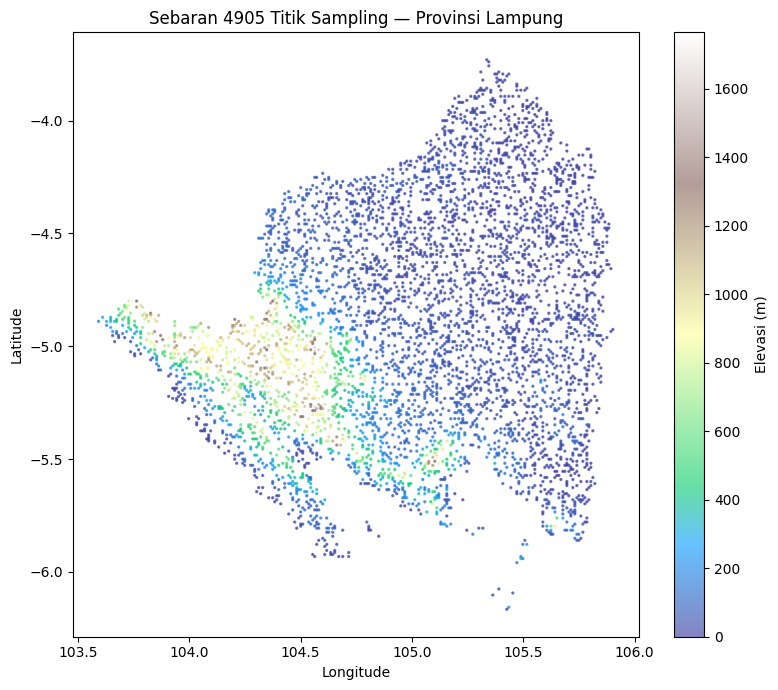

In [ ]:
# Visualisasi sebaran titik
plt.figure(figsize=(8, 7))
scatter = plt.scatter(df['lon'], df['lat'], c=df['elevasi'],
                      cmap='terrain', s=2, alpha=0.6)
plt.colorbar(scatter, label='Elevasi (m)')
plt.title('Sebaran 4905 Titik Sampling — Provinsi Lampung')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

## Langkah 2 — Assign Titik ke Kabupaten

Karena tidak semua environment punya akses shapefile, kita pakai **nearest centroid** (Voronoi assignment).
Tiap titik di-assign ke kabupaten yang centroidnya paling dekat.

> ⚠️ **Catatan metodologi:** Pendekatan ini menggunakan koordinat centroid ibu kota tiap kabupaten sebagai referensi.
> Untuk akurasi lebih tinggi, bisa diganti dengan spatial join menggunakan shapefile resmi (lihat bagian opsional di bawah).

In [ ]:
# Koordinat centroid tiap kabupaten/kota di Lampung
# Format: 'Nama Kabupaten': (longitude, latitude)
kabupaten_centroids = {
    'Lampung Barat':        (104.0700, -5.0667),
    'Tanggamus':            (104.6250, -5.3500),
    'Lampung Selatan':      (105.5500, -5.5500),
    'Lampung Timur':        (105.6000, -4.8500),
    'Lampung Tengah':       (105.1500, -4.6000),
    'Lampung Utara':        (104.7000, -4.3500),
    'Way Kanan':            (104.6000, -4.0500),
    'Tulang Bawang':        (105.5500, -4.1000),
    'Pesawaran':            (105.2000, -5.3000),
    'Pringsewu':            (104.9800, -5.3500),
    'Mesuji':               (105.8000, -3.9500),
    'Tulang Bawang Barat':  (105.0500, -4.2500),
    'Pesisir Barat':        (103.8500, -5.0000),
    'Bandar Lampung':       (105.2650, -5.4000),
    'Metro':                (105.3100, -5.1100),
}

# Buat KD-Tree untuk nearest neighbor search yang efisien
names = list(kabupaten_centroids.keys())
centroids = np.array(list(kabupaten_centroids.values()))  # shape (15, 2)

tree = cKDTree(centroids)
coords = df[['lon', 'lat']].values
distances, indices = tree.query(coords)

df['kabupaten'] = [names[i] for i in indices]
df['jarak_ke_centroid_km'] = (distances * 111).round(1)  # konversi derajat -> km

print('Assignment kabupaten selesai ✅')
print()
print('Jumlah titik per kabupaten:')
print(df['kabupaten'].value_counts())

Assignment kabupaten selesai ✅

Jumlah titik per kabupaten:
kabupaten
Tanggamus              680
Lampung Timur          535
Lampung Tengah         527
Tulang Bawang          498
Lampung Utara          486
Lampung Barat          452
Lampung Selatan        379
Pringsewu              358
Metro                  312
Tulang Bawang Barat    287
Bandar Lampung         154
Pesisir Barat          133
Pesawaran               95
Mesuji                   9
Name: count, dtype: int64


In [ ]:
# Decode kode MODIS ke label tutupan lahan
modis_labels = {
    1:  'Evergreen Needleleaf Forest',
    2:  'Evergreen Broadleaf Forest',
    3:  'Deciduous Needleleaf Forest',
    4:  'Deciduous Broadleaf Forest',
    5:  'Mixed Forests',
    6:  'Closed Shrublands',
    7:  'Open Shrublands',
    8:  'Woody Savannas',
    9:  'Savannas',
    10: 'Grasslands',
    11: 'Permanent Wetlands',
    12: 'Croplands',
    13: 'Urban/Built-up',
    14: 'Cropland/Natural Vegetation Mosaic',
    15: 'Snow and Ice',
    16: 'Barren or Sparsely Vegetated',
    17: 'Water Bodies',
}

df['tutupan_lahan_label'] = df['tutupan_lahan'].map(modis_labels).fillna('Unknown')

print('Decode MODIS selesai ✅')
print()
print('Distribusi tutupan lahan (label):')
print(df['tutupan_lahan_label'].value_counts())

Decode MODIS selesai ✅

Distribusi tutupan lahan (label):
tutupan_lahan_label
Cropland/Natural Vegetation Mosaic    1949
Woody Savannas                        1166
Evergreen Broadleaf Forest             836
Croplands                              407
Savannas                               380
Permanent Wetlands                      59
Water Bodies                            45
Grasslands                              39
Urban/Built-up                          24
Name: count, dtype: int64


## Langkah 3 — Agregasi per Kabupaten

In [ ]:
# Fungsi modus (nilai paling sering)
def modus(series):
    return series.value_counts().index[0]

# Agregasi
agg = df.groupby('kabupaten').agg(
    jumlah_titik        = ('elevasi', 'count'),
    elevasi_mean        = ('elevasi', 'mean'),
    elevasi_min         = ('elevasi', 'min'),
    elevasi_max         = ('elevasi', 'max'),
    elevasi_std         = ('elevasi', 'std'),
    tutupan_dominan     = ('tutupan_lahan_label', modus),
    kode_tutupan_dominan= ('tutupan_lahan', modus),
).reset_index()

# Bulatkan desimal
for col in ['elevasi_mean', 'elevasi_std']:
    agg[col] = agg[col].round(1)

# Urutkan dari elevasi terendah (paling rawan)
agg = agg.sort_values('elevasi_mean')

print('=== HASIL AGREGASI SPASIAL PER KABUPATEN ===')
print()
agg

=== HASIL AGREGASI SPASIAL PER KABUPATEN ===



,kabupaten,jumlah_titik,elevasi_mean,elevasi_min,elevasi_max,elevasi_std,tutupan_dominan,kode_tutupan_dominan
6,Mesuji,9,5.8,4,11,2.8,Permanent Wetlands,11
12,Tulang Bawang,498,12.5,1,48,9.7,Cropland/Natural Vegetation Mosaic,14
4,Lampung Timur,535,21.4,0,74,10.2,Cropland/Natural Vegetation Mosaic,14
3,Lampung Tengah,527,32.2,5,88,13.9,Cropland/Natural Vegetation Mosaic,14
13,Tulang Bawang Barat,287,32.3,6,72,14.2,Cropland/Natural Vegetation Mosaic,14
7,Metro,312,47.6,21,201,18.3,Cropland/Natural Vegetation Mosaic,14
2,Lampung Selatan,379,54.9,2,924,77.4,Cropland/Natural Vegetation Mosaic,14
5,Lampung Utara,486,82.4,18,282,44.7,Woody Savannas,8
8,Pesawaran,95,91.0,50,325,39.7,Cropland/Natural Vegetation Mosaic,14
10,Pringsewu,358,209.8,0,1452,189.1,Woody Savannas,8


---

Threshold elevasi <50 m mengacu pada klasifikasi van Zuidam (1985)
dalam Bonser et al. (2017), yang mendefinisikan wilayah dengan
elevasi ≤50 m dpal sebagai dataran rendah yang rentan terhadap banjir.

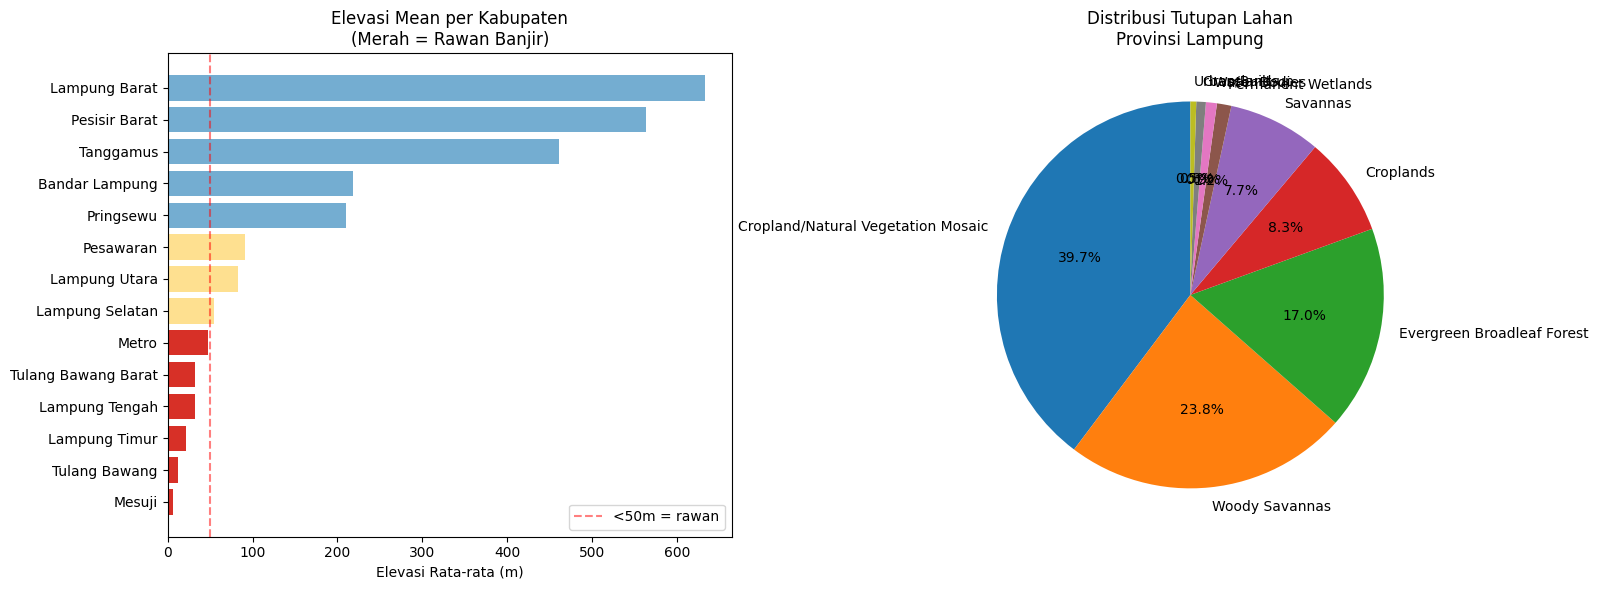

In [ ]:
# Visualisasi elevasi per kabupaten
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Elevasi rata-rata
colors = ['#d73027' if e < 50 else '#fee090' if e < 150 else '#74add1'
          for e in agg['elevasi_mean']]
axes[0].barh(agg['kabupaten'], agg['elevasi_mean'], color=colors)
axes[0].set_xlabel('Elevasi Rata-rata (m)')
axes[0].set_title('Elevasi Mean per Kabupaten\n(Merah = Rawan Banjir)')
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='<50m = rawan')
axes[0].legend()

# Plot 2: Tutupan lahan dominan
tutupan_counts = df['tutupan_lahan_label'].value_counts()
axes[1].pie(tutupan_counts.values, labels=tutupan_counts.index,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribusi Tutupan Lahan\nProvinsi Lampung')

plt.tight_layout()
plt.show()

## Simpan Output

In [ ]:
# Simpan hasil agregasi
agg.to_csv('spasial_per_kabupaten.csv', index=False)

# Simpan dataframe lengkap (dengan kolom kabupaten & lon/lat)
df_out = df[['system:index', 'elevasi', 'tutupan_lahan', 'tutupan_lahan_label',
             'lon', 'lat', 'kabupaten', 'jarak_ke_centroid_km']]
df_out.to_csv('spasial_titik_lengkap.csv', index=False)

print('File tersimpan:')
print('  spasial_per_kabupaten.csv  — agregasi per kabupaten (untuk digabung dengan data lain)')
print('  spasial_titik_lengkap.csv  — semua 4905 titik dengan label kabupaten')

# Preview hasil akhir
print()
print('Preview spasial_per_kabupaten.csv:')
agg[['kabupaten', 'elevasi_mean', 'elevasi_min', 'elevasi_max', 'tutupan_dominan']]

File tersimpan:
  spasial_per_kabupaten.csv  — agregasi per kabupaten (untuk digabung dengan data lain)
  spasial_titik_lengkap.csv  — semua 4905 titik dengan label kabupaten

Preview spasial_per_kabupaten.csv:


,kabupaten,elevasi_mean,elevasi_min,elevasi_max,tutupan_dominan
6,Mesuji,5.8,4,11,Permanent Wetlands
12,Tulang Bawang,12.5,1,48,Cropland/Natural Vegetation Mosaic
4,Lampung Timur,21.4,0,74,Cropland/Natural Vegetation Mosaic
3,Lampung Tengah,32.2,5,88,Cropland/Natural Vegetation Mosaic
13,Tulang Bawang Barat,32.3,6,72,Cropland/Natural Vegetation Mosaic
7,Metro,47.6,21,201,Cropland/Natural Vegetation Mosaic
2,Lampung Selatan,54.9,2,924,Cropland/Natural Vegetation Mosaic
5,Lampung Utara,82.4,18,282,Woody Savannas
8,Pesawaran,91.0,50,325,Cropland/Natural Vegetation Mosaic
10,Pringsewu,209.8,0,1452,Woody Savannas
